# laser_driver_v3 — Differential Beat-Frequency Uncertainty Budget

**Dynamic uncertainty budget comparing the kHz current-dither lock with an MHz analog-derivative (RF) lock**, for the two-ring (reference + sensor) Pound–Drever–Hall beat-frequency instrument.

This notebook keeps every input as an editable variable. The physics-based contributors (thermal gradient, thermal sensitivity mismatch, detection floor, timebase) are **computed live** from those inputs; the remaining contributors are adjustable engineering estimates. The final cell regenerates the clean comparison table.

> All values are **1σ standard uncertainties in Hz** on the differential beat frequency Δν. They are planning estimates (mostly Type B by judgement) and should be replaced by measured Allan / scatter data once the instrument is built.

## 1. Acronyms, symbols, and definitions

### Optical / resonator
| Term | Definition |
|---|---|
| CW | Continuous-wave — constant (non-pulsed) optical output |
| DFB | Distributed-feedback — single-mode semiconductor laser (the 1550 nm sources) |
| PD | Photodiode |
| InGaAs | Indium gallium arsenide — photodiode material responsive at 1550 nm |
| MPD | Monitor photodiode — laser back-facet power monitor |
| TEC | Thermoelectric cooler — Peltier element for temperature control |
| NTC | Negative temperature coefficient — thermistor used for temperature sensing |
| SiN | Silicon nitride — low-loss waveguide / microring material |
| ULE | Ultra-low-expansion glass — used for stable optical reference cavities |
| Q | Quality factor — resonator sharpness, Q = ν₀ / FWHM |
| FSR | Free spectral range — frequency spacing between resonator modes |

### Modulation and locking
| Term | Definition |
|---|---|
| PDH | Pound–Drever–Hall — laser-to-cavity frequency-locking technique |
| RF | Radio frequency |
| FM | Frequency modulation |
| AM | Amplitude modulation |
| RAM | Residual amplitude modulation — unwanted AM accompanying phase/frequency modulation |
| EOM | Electro-optic modulator — external phase modulator |
| DDS | Direct digital synthesis — the AD9833 generating the modulation tone |
| LO | Local oscillator — reference tone used for demodulation |
| ACC | Automatic current control — constant-current laser drive mode |
| APC | Automatic power control — constant-optical-power laser drive mode |
| DAC | Digital-to-analog converter |
| ADC | Analog-to-digital converter |
| DMA | Direct memory access — used for the Teensy ADC sampling |
| β | Modulation index — peak phase deviation (FM excursion / modulation frequency) |
| Ω | Modulation (angular) frequency |

### Detection and signal chain
| Term | Definition |
|---|---|
| TIA | Transimpedance amplifier — converts photocurrent to voltage |
| AAF | Anti-aliasing filter |
| SNR | Signal-to-noise ratio |
| SFDR | Spurious-free dynamic range — cleanliness of the DDS output spectrum |
| BW | Bandwidth |
| PSD | Power spectral density |
| RIN | Relative intensity noise — laser intensity fluctuations (dBc/Hz) |
| PLL | Phase-locked loop |

### Frequency reference and readout
| Term | Definition |
|---|---|
| FWHM | Full width at half maximum — resonance linewidth |
| HWHM | Half width at half maximum |
| FFT | Fast Fourier transform |
| TCXO | Temperature-compensated crystal oscillator |
| OCXO | Oven-controlled crystal oscillator |
| GPSDO | GPS-disciplined oscillator |
| CMRR | Common-mode rejection ratio |

### Metrology / statistics
| Term | Definition |
|---|---|
| GUM | Guide to the Expression of Uncertainty in Measurement (ISO/JCGM 100) |
| Type A | Uncertainty evaluated by statistical analysis of repeated observations |
| Type B | Uncertainty evaluated by other means (datasheets, modelling, judgement) |
| u_c | Combined standard uncertainty — quadrature sum of components (coverage factor k = 1) |
| U | Expanded uncertainty — U = k · u_c |
| k | Coverage factor — k = 2 gives ≈ 95 % coverage for a normal distribution |
| R&R | Repeatability and reproducibility |
| Repeatability | Variation under identical conditions, short term, one setup/operator/lock |
| Reproducibility | Variation under changed conditions — re-lock, day-to-day, operator |
| Allan deviation | Time-domain frequency-stability measure σ_y(τ) |

### Symbols used in the model
| Symbol | Meaning |
|---|---|
| ν₀ | Optical carrier frequency (≈ 193.4 THz at 1550 nm) |
| Δν | Beat (difference) frequency between the two locked lasers |
| S = dν/dT | Ring frequency–temperature sensitivity (≈ 2 GHz/K, thermo-optic dominated) |
| ε | Fractional mismatch between the two rings' temperature coefficients |
| ΔT_common | Common (shared) absolute temperature excursion of both rings |
| ΔT_diff | Differential temperature between the two rings (gradient) |
| τ | Averaging / measurement time |
| σ | Standard deviation / Allan deviation |
| f_u | Servo (loop) unity-gain bandwidth |

## 2. Architecture and modelling assumptions

**Two-ring differential scheme.** Ring A is the *environmental reference* (locked to track temperature/strain); ring B is the *sensor*. The measurement is the beat **Δν = ν_B − ν_A**. Effects common to both rings cancel; what survives is the residual.

**Common-mode residual splits into two terms** (both independent of the modulation scheme):
- *Thermal gradient*: the rings sit at slightly different temperatures → `u = ΔT_diff · S`.
- *Thermal sensitivity mismatch*: a **common** swing produces a **differential** shift through fab tolerance in the rings' temperature coefficients → `u = ε · ΔT_common · S`. This does **not** vanish at ΔT_diff = 0.

**What does NOT cancel** via the reference ring: each ring has its own laser and detector, so laser FM noise and detection noise stay uncorrelated and add in quadrature. The MHz RF lock attacks exactly those per-channel terms, which is why it is orthogonal to (and complementary with) the reference-ring scheme.

**"RF" here** = MHz analog-derivative (FM/lock-in) lock. True dispersive PDH is not reachable on a Q = 1e5 (≈1.9 GHz wide) ring, so the RF case is the slow-modulation derivative lock at higher carrier with an analog demodulator.

**Conditions.** Repeatability = short term, fixed conditions, averaging time τ. Reproducibility = re-lock + day-to-day. Detection floor is white-FM and evaluated at τ; it is re-used in the reproducibility column (re-acquisition floor).

In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

C = 299_792_458.0  # speed of light [m/s]

In [2]:
@dataclass
class Params:
    # --- optical / resonator ---
    lam: float        = 1550e-9   # laser wavelength [m]
    Q: float          = 1e5       # loaded resonator quality factor
    dnu_dT: float     = 2.0e9     # ring frequency-temperature sensitivity S [Hz/K]

    # --- beat / readout ---
    Delta_nu: float   = 100e6     # nominal beat frequency [Hz]
    fs_span: float    = 20e9      # full-scale measurand range of Delta_nu [Hz]
    tau: float        = 1.0       # per-measurement averaging time [s] (repeatability)

    # --- detection white-FM sqrt-PSD, per channel [Hz/sqrt(Hz)] ---
    # differential floor at averaging time tau is psd/sqrt(tau)
    det_psd_dither: float = 150.0   # RIN-limited at the kHz dither band
    det_psd_rf: float     = 20.0    # demodulated above the RIN / 1-f corner

    # --- thermal (reference/sensor common-mode residuals) ---
    eps: float            = 1.0e-3  # fractional temp-coefficient mismatch between rings
    dT_common_rep: float  = 10e-6   # common abs. excursion, short term [K]
    dT_common_repro: float= 1.0e-3  # common abs. excursion, run-to-run [K]
    dT_diff_rep: float    = 10e-9   # differential (gradient), short term [K]
    dT_diff_repro: float  = 1.0e-6  # differential (gradient), run-to-run [K]

    # --- timebase fractional stability (readout clock) ---
    frac_dither: float = 1e-6   # 25 MHz crystal (as-built)
    frac_rf: float     = 1e-8   # OCXO (recommended with the RF upgrade)

    # --- adjustable engineering estimates: (repeatability, reproducibility) [Hz] ---
    laser_fm_dither: tuple = (300.0, 300.0)
    laser_fm_rf:     tuple = (10.0, 10.0)
    smear_dither:    tuple = (50.0, 80.0)   # carrier dither-excursion residual
    smear_rf:        tuple = (0.0, 0.0)     # no carrier sweep in the RF lock
    rin_dither:      tuple = (100.0, 400.0) # RIN -> lock-point pulling
    rin_rf:          tuple = (8.0, 15.0)
    ram_dither:      tuple = (50.0, 500.0)  # line-shape / RAM lock offset (differential)
    ram_rf:          tuple = (10.0, 50.0)
    strain:          tuple = (30.0, 150.0)  # differential strain / vibration (common to both)

    # --- coverage factor ---
    k: float = 2.0

    # derived
    @property
    def nu0(self):   return C / self.lam
    @property
    def fwhm(self):  return self.nu0 / self.Q


In [3]:
def detection_diff(psd, tau):
    """Differential detection floor [Hz] = sqrt(2) * per-channel sigma(tau)."""
    return psd / np.sqrt(tau)               # = sqrt(2)*psd*sqrt(1/(2*tau))

def thermal_gradient(dT_diff, S):
    """Residual from a temperature gradient between the rings [Hz]."""
    return dT_diff * S

def thermal_mismatch(eps, dT_common, S):
    """Residual from temp-coefficient mismatch on a common swing [Hz]."""
    return eps * dT_common * S

def timebase(frac, Delta_nu):
    """Counter-reference contribution [Hz] = fractional stability * beat frequency."""
    return frac * Delta_nu


In [4]:
def build_budget(p: Params):
    S = p.dnu_dT
    det_d = detection_diff(p.det_psd_dither, p.tau)
    det_r = detection_diff(p.det_psd_rf,     p.tau)

    g_rep,  g_rep2  = thermal_gradient(p.dT_diff_rep, S),  thermal_gradient(p.dT_diff_repro, S)
    m_rep,  m_rep2  = thermal_mismatch(p.eps, p.dT_common_rep, S), thermal_mismatch(p.eps, p.dT_common_repro, S)

    tb_d = timebase(p.frac_dither, p.Delta_nu)
    tb_r = timebase(p.frac_rf,     p.Delta_nu)

    # rows: name, type, (d_rep, d_repro, rf_rep, rf_repro)
    rows = [
        ("Detection / discrimination noise",      "A . mod", (det_d, det_d, det_r, det_r)),
        ("Residual laser FM above loop BW",        "A . mod", (p.laser_fm_dither[0], p.laser_fm_dither[1], p.laser_fm_rf[0], p.laser_fm_rf[1])),
        ("Carrier-dither smear residual",          "A . mod", (p.smear_dither[0], p.smear_dither[1], p.smear_rf[0], p.smear_rf[1])),
        ("RIN -> lock-point pulling",              "B . mod", (p.rin_dither[0], p.rin_dither[1], p.rin_rf[0], p.rin_rf[1])),
        ("Line-shape / RAM lock offset",           "B . mod", (p.ram_dither[0], p.ram_dither[1], p.ram_rf[0], p.ram_rf[1])),
        ("Thermal - gradient (dT_diff . S)",       "B . env", (g_rep, g_rep2, g_rep, g_rep2)),
        ("Thermal - sensitivity mismatch (e.S.dTc)","B . env", (m_rep, m_rep2, m_rep, m_rep2)),
        ("Strain / vibration (differential)",      "B . env", (p.strain[0], p.strain[1], p.strain[0], p.strain[1])),
        ("Timebase / counter reference",           "B . read",(tb_d, tb_d, tb_r, tb_r)),
    ]

    data = np.array([r[2] for r in rows], dtype=float)          # (n_rows, 4)
    uc = np.sqrt((data**2).sum(axis=0))                          # combined standard uncertainty
    U  = p.k * uc                                                # expanded uncertainty

    cols = ["Dither - repeat.", "Dither - reprod.", "RF - repeat.", "RF - reprod."]
    df = pd.DataFrame(data, columns=cols)
    df.insert(0, "Type", [r[1] for r in rows])
    df.insert(0, "Contributor", [r[0] for r in rows])

    frac_uc = uc / p.nu0                 # dimensionless (Hz / Hz), referenced to optical carrier
    frac_U  = U  / p.nu0
    fs_uc   = uc / p.fs_span             # referenced to full-scale measurand span
    fs_U    = U  / p.fs_span
    bits    = np.log2(p.fs_span / uc)    # effective resolution over full scale [bits]
    ef = lambda x: f"{x:.2e}"
    summary = pd.DataFrame(
        [["Combined standard uncertainty u_c (k=1)", ""] + list(uc),
         [f"Expanded uncertainty U (k={p.k:g}, ~95%)", ""] + list(U),
         ["Fractional u_c  (Δν/ν₀, carrier)", ""] + [ef(v) for v in frac_uc],
         [f"Fractional U  (Δν/ν₀, k={p.k:g})", ""] + [ef(v) for v in frac_U],
         [f"Fractional u_c  (Δν/FS, FS={p.fs_span/1e9:g} GHz)", ""] + [ef(v) for v in fs_uc],
         [f"Fractional U  (Δν/FS, k={p.k:g})", ""] + [ef(v) for v in fs_U],
         ["Effective resolution over FS [bits]", ""] + [f"{b:.1f}" for b in bits]],
        columns=df.columns)
    full = pd.concat([df, summary], ignore_index=True)
    return full, dict(uc=uc, U=U, frac_uc=frac_uc, frac_U=frac_U,
                      fs_uc=fs_uc, fs_U=fs_U, bits=bits, cols=cols,
                      nu0=p.nu0, fwhm=p.fwhm, det_d=det_d, det_r=det_r)


## 3. Run the budget

Edit any field in `Params(...)` and re-run. The thermal, detection, and timebase rows update automatically.

In [5]:
def fmt_cell(v):
    if isinstance(v, str): return v
    if v == 0: return "—"
    return f"{v:,.0f}"

def show(df, bold_from=None):
    disp = df.copy()
    num = ["Dither - repeat.", "Dither - reprod.", "RF - repeat.", "RF - reprod."]
    for c in num:
        disp[c] = disp[c].map(fmt_cell)
    is_summary = df["Type"].astype(str).str.strip().eq("").tolist()   # summary rows have blank Type
    sty = disp.style.hide(axis="index").set_properties(subset=num, **{"text-align": "right"})
    sty = sty.apply(lambda r: ["font-weight: 700" if is_summary[r.name] else "" for _ in r], axis=1)
    return sty

p = Params()
full, info = build_budget(p)
print(f"nu0 = {info['nu0']:.4e} Hz   FWHM = {info['fwhm']:.3e} Hz "
      f"({info['fwhm']/1e9:.2f} GHz)   detection diff: dither {info['det_d']:.0f} Hz, RF {info['det_r']:.0f} Hz")
show(full, bold_from=len(full)-2)


nu0 = 1.9341e+14 Hz   FWHM = 1.934e+09 Hz (1.93 GHz)   detection diff: dither 150 Hz, RF 20 Hz


Contributor,Type,Dither - repeat.,Dither - reprod.,RF - repeat.,RF - reprod.
Detection / discrimination noise,A . mod,150,150,20,20
Residual laser FM above loop BW,A . mod,300,300,10,10
Carrier-dither smear residual,A . mod,50,80,—,—
RIN -> lock-point pulling,B . mod,100,400,8,15
Line-shape / RAM lock offset,B . mod,50,500,10,50
Thermal - gradient (dT_diff . S),B . env,20,"2,000",20,"2,000"
Thermal - sensitivity mismatch (e.S.dTc),B . env,20,"2,000",20,"2,000"
Strain / vibration (differential),B . env,30,150,30,150
Timebase / counter reference,B . read,100,100,1,1
Combined standard uncertainty u_c (k=1),,373,"2,926",49,"2,833"


## 4. Thermal-term sensitivity (what spec hits a target)

Both thermal rows scale linearly, so for any target per-term uncertainty `T` (1σ, Hz):

- gradient needs `ΔT_diff ≤ T / S`
- mismatch needs `ε · ΔT_common ≤ T / S`  → `ΔT_common ≤ T / (S · ε)`

In [6]:
def thermal_targets(p: Params, targets_Hz=(2000, 200, 20), eps_examples=(1e-3, 1e-2)):
    S = p.dnu_dT
    rows = []
    for T in targets_Hz:
        dTdiff = T / S
        prod   = T / S                      # eps * dT_common
        row = {"Target per term (Hz)": f"{T:,.0f}",
               "Gradient: dT_diff": f"{dTdiff*1e9:.3g} nK",
               "Mismatch: e.dT_common (K)": f"{prod:.2e}"}
        for e in eps_examples:
            row[f"dT_common @ e={e:g}"] = f"{prod/e*1e6:.3g} uK"
        rows.append(row)
    return pd.DataFrame(rows)

tt = thermal_targets(p)
tt.style.hide(axis="index")


Target per term (Hz),Gradient: dT_diff,Mismatch: e.dT_common (K),dT_common @ e=0.001,dT_common @ e=0.01
"2,000",1e+03 nK,1.00e-06,1e+03 uK,100 uK
200,100 nK,1.00e-07,100 uK,10 uK
20,10 nK,1.00e-08,10 uK,1 uK


## 5. Optional — interactive sliders (Colab-ready)

On Google Colab, widgets need the custom widget manager enabled first — this cell does that automatically, and installs `ipywidgets` only if it is genuinely missing. Drag the sliders to watch `u_c` update. If widgets still misbehave (stale kernel), skip to section 5b, which needs no widgets at all.

In [7]:
# Colab needs its custom widget manager turned on before interact will render/update.
try:
    from google.colab import output as _co
    _co.enable_custom_widget_manager()
except Exception:
    pass

try:
    import ipywidgets as W
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as W
from IPython.display import display

def interactive_budget(Q=1e5, eps_log=-3.0, dTc_repro_uK=1000.0,
                       dTd_repro_nK=1000.0, det_psd_rf=20.0, Delta_nu_MHz=100.0,
                       frac_rf_log=-8.0):
    p = Params(Q=Q, eps=10**eps_log,
               dT_common_repro=dTc_repro_uK*1e-6,
               dT_diff_repro=dTd_repro_nK*1e-9,
               det_psd_rf=det_psd_rf,
               Delta_nu=Delta_nu_MHz*1e6,
               frac_rf=10**frac_rf_log)
    full, info = build_budget(p)
    uc = info["uc"]
    print(f"u_c  [Hz]:  dither rep {uc[0]:7.0f}  repro {uc[1]:7.0f}   |   "
          f"RF rep {uc[2]:7.0f}  repro {uc[3]:7.0f}")
    display(show(full, bold_from=len(full)-2))

W.interact(interactive_budget,
           Q=W.FloatLogSlider(value=1e5, base=10, min=4, max=8, description="Q"),
           eps_log=W.FloatSlider(value=-3, min=-5, max=-1, step=0.25, description="log10(eps)"),
           dTc_repro_uK=W.FloatLogSlider(value=1000, base=10, min=0, max=4, description="dT_common [uK]"),
           dTd_repro_nK=W.FloatLogSlider(value=1000, base=10, min=0, max=4, description="dT_diff [nK]"),
           det_psd_rf=W.FloatSlider(value=20, min=2, max=200, step=2, description="RF det PSD"),
           Delta_nu_MHz=W.FloatSlider(value=100, min=1, max=1000, step=1, description="beat [MHz]"),
           frac_rf_log=W.FloatSlider(value=-8, min=-10, max=-6, step=0.5, description="log10(clk)"));


interactive(children=(FloatLogSlider(value=100000.0, description='Q', max=8.0, min=4.0), FloatSlider(value=-3.…

### 5b. No-widget alternative

Always works on any runtime — call `recompute(...)` with any `Params` field(s) to override and re-display.

In [8]:
def recompute(**overrides):
    p = Params(**overrides)
    full, info = build_budget(p)
    uc = info["uc"]
    print(f"u_c [Hz]:  dither {uc[0]:.0f}/{uc[1]:.0f}   RF {uc[2]:.0f}/{uc[3]:.0f}")
    return show(full, bold_from=len(full)-2)

# examples - edit and re-run:
recompute(Q=1e7, eps=1e-4, dT_diff_repro=10e-9, dT_common_repro=1e-5)


u_c [Hz]:  dither 373/750   RF 44/162


Contributor,Type,Dither - repeat.,Dither - reprod.,RF - repeat.,RF - reprod.
Detection / discrimination noise,A . mod,150,150,20,20
Residual laser FM above loop BW,A . mod,300,300,10,10
Carrier-dither smear residual,A . mod,50,80,—,—
RIN -> lock-point pulling,B . mod,100,400,8,15
Line-shape / RAM lock offset,B . mod,50,500,10,50
Thermal - gradient (dT_diff . S),B . env,20,20,20,20
Thermal - sensitivity mismatch (e.S.dTc),B . env,2,2,2,2
Strain / vibration (differential),B . env,30,150,30,150
Timebase / counter reference,B . read,100,100,1,1
Combined standard uncertainty u_c (k=1),,373,750,44,162


## 6. Optional — reproducibility vs differential thermal

Shows the thermal wall: combined reproducibility uncertainty as ΔT_diff is swept, for both schemes. Needs `matplotlib`.

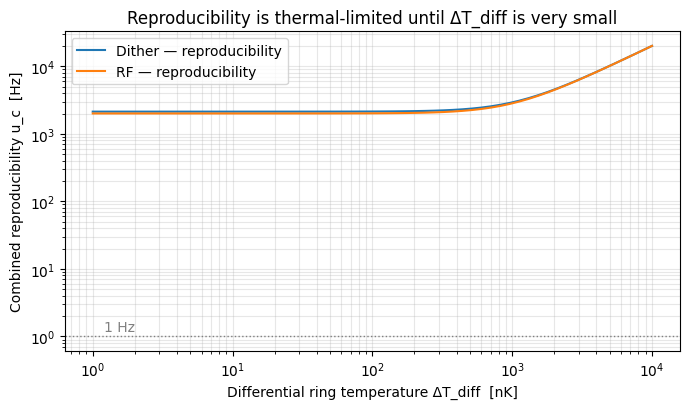

In [9]:
try:
    import matplotlib.pyplot as plt
    dTd = np.logspace(-9, -5, 60)            # 1 nK ... 10 uK
    uc_d, uc_r = [], []
    for x in dTd:
        pp = Params(dT_diff_repro=x)
        _, inf = build_budget(pp)
        uc_d.append(inf["uc"][1]); uc_r.append(inf["uc"][3])
    fig, ax = plt.subplots(figsize=(7,4.2))
    ax.loglog(dTd*1e9, uc_d, label="Dither — reproducibility")
    ax.loglog(dTd*1e9, uc_r, label="RF — reproducibility")
    ax.axhline(1, ls=":", c="gray", lw=1); ax.text(1.2, 1.2, "1 Hz", color="gray")
    ax.set_xlabel("Differential ring temperature ΔT_diff  [nK]")
    ax.set_ylabel("Combined reproducibility u_c  [Hz]")
    ax.set_title("Reproducibility is thermal-limited until ΔT_diff is very small")
    ax.legend(); ax.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed - skip the plot.")


## 7. Clean comparison table (final)

Regenerates the table exactly as presented in the design review — rendered as a styled table and also emitted as Markdown for pasting into the project HTML / report.

In [10]:
def to_markdown_table(df, bold_from=None):
    cols = list(df.columns)
    num = set(["Dither - repeat.", "Dither - reprod.", "RF - repeat.", "RF - reprod."])
    header = "| " + " | ".join(cols) + " |"
    sep    = "|" + "|".join([" ---: " if c in num else " --- " for c in cols]) + "|"
    lines = [header, sep]
    n = len(df)
    for i, (_, row) in enumerate(df.iterrows()):
        cells = [fmt_cell(row[c]) for c in cols]
        if str(row["Type"]).strip() == "":          # summary rows have blank Type
            cells = [f"**{c}**" if str(c).strip() else "" for c in cells]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)

p = Params()
full, info = build_budget(p)

# styled display
display(show(full, bold_from=len(full)-2))

# markdown for export
md_str = to_markdown_table(full, bold_from=len(full)-2)
print(md_str)


Contributor,Type,Dither - repeat.,Dither - reprod.,RF - repeat.,RF - reprod.
Detection / discrimination noise,A . mod,150,150,20,20
Residual laser FM above loop BW,A . mod,300,300,10,10
Carrier-dither smear residual,A . mod,50,80,—,—
RIN -> lock-point pulling,B . mod,100,400,8,15
Line-shape / RAM lock offset,B . mod,50,500,10,50
Thermal - gradient (dT_diff . S),B . env,20,"2,000",20,"2,000"
Thermal - sensitivity mismatch (e.S.dTc),B . env,20,"2,000",20,"2,000"
Strain / vibration (differential),B . env,30,150,30,150
Timebase / counter reference,B . read,100,100,1,1
Combined standard uncertainty u_c (k=1),,373,"2,926",49,"2,833"


| Contributor | Type | Dither - repeat. | Dither - reprod. | RF - repeat. | RF - reprod. |
| --- | --- | ---: | ---: | ---: | ---: |
| Detection / discrimination noise | A . mod | 150 | 150 | 20 | 20 |
| Residual laser FM above loop BW | A . mod | 300 | 300 | 10 | 10 |
| Carrier-dither smear residual | A . mod | 50 | 80 | — | — |
| RIN -> lock-point pulling | B . mod | 100 | 400 | 8 | 15 |
| Line-shape / RAM lock offset | B . mod | 50 | 500 | 10 | 50 |
| Thermal - gradient (dT_diff . S) | B . env | 20 | 2,000 | 20 | 2,000 |
| Thermal - sensitivity mismatch (e.S.dTc) | B . env | 20 | 2,000 | 20 | 2,000 |
| Strain / vibration (differential) | B . env | 30 | 150 | 30 | 150 |
| Timebase / counter reference | B . read | 100 | 100 | 1 | 1 |
| **Combined standard uncertainty u_c (k=1)** |  | **373** | **2,926** | **49** | **2,833** |
| **Expanded uncertainty U (k=2, ~95%)** |  | **746** | **5,852** | **97** | **5,666** |
| **Fractional u_c  (Δν/ν₀, carrier)** |  | **1.93e-12** | **1.51e-11** 

---
*Generated for laser_driver_v3. Replace Type-B estimates with measured Allan/scatter data as the instrument is characterised; the thermal, detection, and timebase rows will then anchor the model and the estimate rows can be tightened or removed.*